In [90]:
import matplotlib.pyplot as plt
import numpy as np

## V4

In [91]:
BATCH_SIZE = 8192

loss_V4 = []
batch_V4 = []
minimum_loss_V4 = float('inf')

with open("./standard_log_V4_2.txt", "r") as f:
    for line in f.readlines():
        if (line.startswith("Epoch")):
            loss_V4.append(float(line.strip().split("|")[1].strip().split(":")[1].strip()))
            minimum_loss_V4 = min(minimum_loss_V4, loss_V4[-1])
            
            batch_epoch = line.strip().split("|")[0].strip()
            epoch = int(batch_epoch.split(",")[0].strip().split(" ")[1].strip())
            batch_num = int(batch_epoch.split(",")[1].strip().split(" ")[1].strip())
            batch_V4.append(((epoch * 1400 + batch_num) * BATCH_SIZE) // 1000000)  # Convertit en millions de positions
            

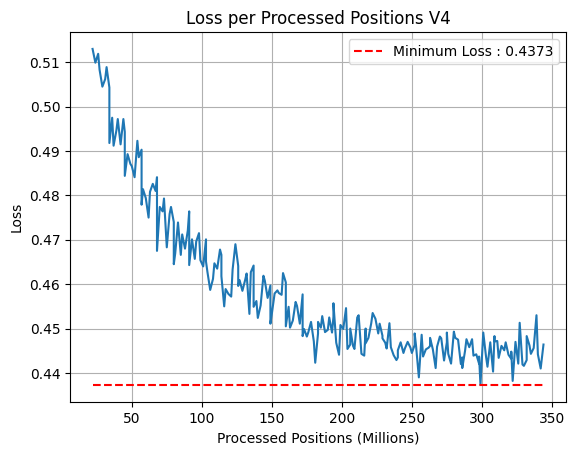

In [92]:
plt.plot(batch_V4, loss_V4)
plt.xlabel("Processed Positions (Millions)")
plt.ylabel("Loss")
plt.title("Loss per Processed Positions V4")
plt.plot([batch_V4[0], batch_V4[-1]], [minimum_loss_V4 , minimum_loss_V4], 'r--', label=f'Minimum Loss : {minimum_loss_V4:.4f}')  # Mark the minimum loss point
plt.grid()
plt.legend()
plt.show()

## V4.5

In [93]:
BATCH_SIZE = 8192

loss_V4_5 = []
batch_V4_5 = []
minimum_loss_V4_5 = float('inf')

with open("./standard_log_V4.5_2.txt", "r") as f:
    for line in f.readlines():
        if (line.startswith("Epoch")):
            loss_V4_5.append(float(line.strip().split("|")[1].strip().split(":")[1].strip()))
            minimum_loss_V4_5 = min(minimum_loss_V4_5, loss_V4_5[-1])
            
            batch_epoch = line.strip().split("|")[0].strip()
            epoch = int(batch_epoch.split(",")[0].strip().split(" ")[1].strip())
            batch_num = int(batch_epoch.split(",")[1].strip().split(" ")[1].strip())
            batch_V4_5.append(((epoch * 1400 + batch_num) * BATCH_SIZE) // 1000000)  # Convertit en millions de positions


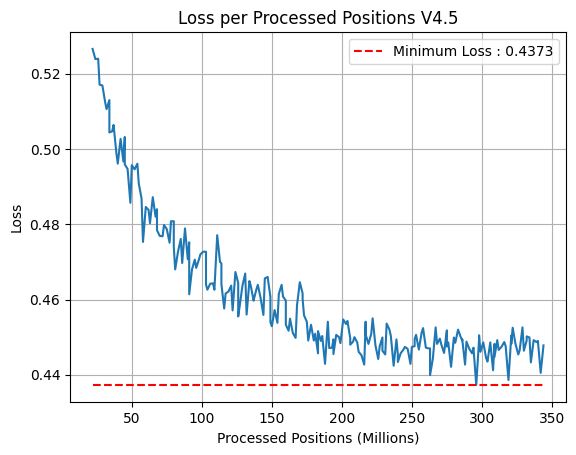

In [94]:
plt.plot(batch_V4_5, loss_V4_5)
plt.xlabel("Processed Positions (Millions)")
plt.ylabel("Loss")
plt.title("Loss per Processed Positions V4.5")
plt.plot([batch_V4_5[0], batch_V4_5[-1]], [minimum_loss_V4_5 , minimum_loss_V4_5], 'r--', label=f'Minimum Loss : {minimum_loss_V4_5:.4f}')  # Mark the minimum loss point
plt.legend()
plt.grid()
plt.show()

## Comparaison

C:\Users\yount\AppData\Local\Temp\ipykernel_812\1988174932.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


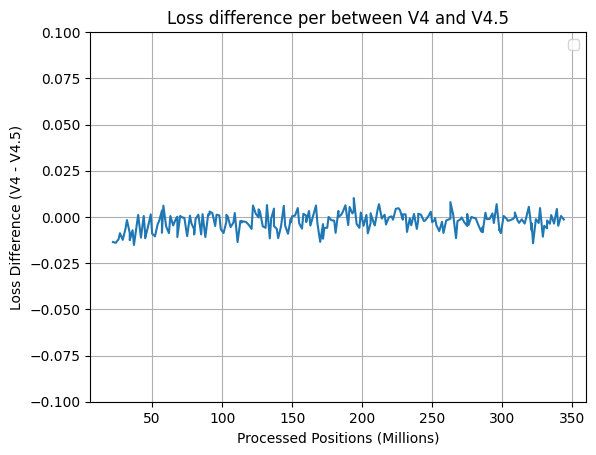

In [102]:
# V45 =  np.array(np.concatenate([batch_V4_5, [0]*(len(batch_V4)-len(batch_V4_5))]))
difference = np.subtract(np.array(loss_V4), np.array(loss_V4_5))
plt.plot(batch_V4, difference)
plt.xlabel("Processed Positions (Millions)")
plt.ylabel("Loss Difference (V4 - V4.5)")
plt.title("Loss difference per between V4 and V4.5")
# plt.plot([batch_V4_5[0], batch_V4_5[-1]], [minimum_loss_V4_5 , minimum_loss_V4_5], 'r--', label=f'Minimum Loss : {minimum_loss_V4_5:.4f}')  # Mark the minimum loss point
plt.legend()
plt.ylim(-0.1, 0.1)  # Adjust the y-axis limits to better visualize the differences
plt.grid()
plt.show()